# EDA of high_diamond_ranked_10min.csv

## Import data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

file_path = '../data/raw/high_diamond_ranked_10min.csv'
df = pd.read_csv(file_path)

# print a summary of the data
print(df.shape)
df.head()

(9879, 40)


,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


Check the amount of missing values in the data, describe some of the data and look at win rates of blue (sanity checks)

In [4]:
# df doesn't have any missing values
df.isnull().sum()

# check stats
df.describe()

# check win rate for blue (about 50% so data is fair)
df['blueWins'].value_counts(normalize=True)

blueWins
0    0.500962
1    0.499038
Name: proportion, dtype: float64

## Checking features that affect winrate

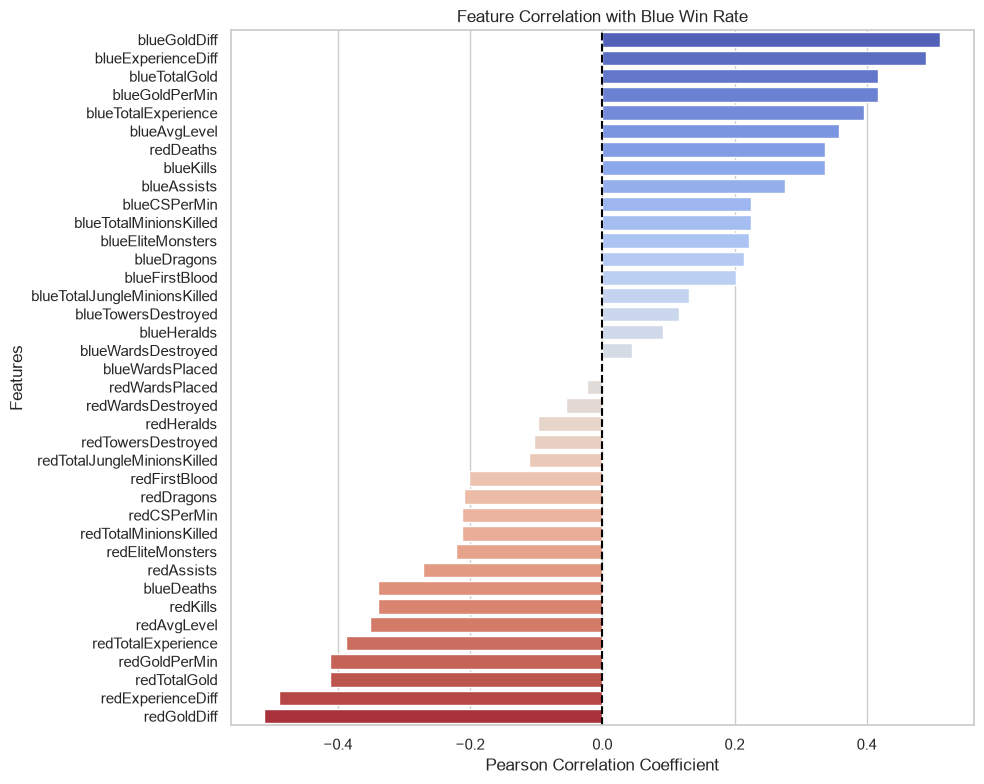

In [15]:
# calculate series to store correlations to wins
correlations = df.corr()['blueWins'].drop(['blueWins', 'gameId']).sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(
    x=correlations.values,
    y=correlations.index,
    hue=correlations.index,
    palette='coolwarm'
)

plt.axvline(0, color='black', linestyle='--')
plt.title('Feature Correlation with Blue Win Rate')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

Something we need to consider for context is the snowball effect. In league an advantage in kills can mean a gold advantage which can naturally mean more map control and more objectives.

This means many features will have multicollinearity since they are all somewhat related. So need to consider a model that deals with multicollinearity very well

Something we can see from the figure is that the red teams stats correlation at 10 mins are essentially symmetrical to the blue teams stats correlation. The only stat for both sides that have negative correlation with the win rate is 'deaths' which is obvious.

This means we should engineer features that focus on the differential between the teams stats since a higher differential means a much higher win rate even if the team isn't doing that well in the stat compared to the average team.

## Engineering features